Absolute Path Fix

In [1]:
import sys
import os

# 1. Get current notebook directory
notebook_dir = os.path.abspath(os.getcwd())

# 2. Get project root (assuming notebook is in a subfolder like 'notebooks/')
project_root = os.path.dirname(notebook_dir)

# 3. Add to path
if project_root not in sys.path:
    sys.path.append(project_root)

# 4. Define paths for Data and Models relative to root
DATA_PATH = os.path.join(project_root, "data", "cleaned_products.csv")
MODEL_PATH = os.path.join(project_root, "models", "content_engine.pkl")

print(f"Project Root: {project_root}")
print(f"Data Path: {DATA_PATH}")

Project Root: D:\Projects\orbit_recommender
Data Path: D:\Projects\orbit_recommender\data\cleaned_products.csv


Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

# Check Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Content Engine initializing on device: {device}")

# Styles
sns.set_style("whitegrid")

Content Engine initializing on device: cuda


Data Loading & Logic

In [3]:
def load_and_process_data():
    if not os.path.exists(DATA_PATH):
         print(f"❌ Error: Could not find data file at {DATA_PATH}")
         return pd.DataFrame()

    print("Loading raw data from CSV...")
    df = pd.read_csv(DATA_PATH)
    
    # Fill missing values to prevent errors
    df['title'] = df['title'].fillna("")
    df['categoryName'] = df['categoryName'].fillna("")
    
    # Create 'Tags': The combined text the AI will read
    # We combine Title + Category for better context
    df['tags'] = df['title'] + " " + df['categoryName']
    
    return df

# Execute
df_content = load_and_process_data()
print(f"✅ Data Loaded. Total Products: {len(df_content)}")
df_content.head(3)

Loading raw data from CSV...
✅ Data Loaded. Total Products: 48681


,asin,title,imgUrl,productURL,stars,reviews,price,isBestSeller,boughtInLastMonth,categoryName,tags
0,B07BR3F9N6,Official Creality Ender 3 3D Printer Fully Ope...,https://m.media-amazon.com/images/I/61L4aoIqYO...,https://www.amazon.co.uk/dp/B07BR3F9N6,4.3,14767,165.0,False,0,3D Printers,Official Creality Ender 3 3D Printer Fully Ope...
1,B07GYRQVYV,Creality Official Ender 3 Pro 3D Printer with ...,https://m.media-amazon.com/images/I/51ZWOI8Lxi...,https://www.amazon.co.uk/dp/B07GYRQVYV,4.4,8938,196.0,False,0,3D Printers,Creality Official Ender 3 Pro 3D Printer with ...
2,B07FFTHMMN,Official Creality Ender 3 V2 3D Printer with 3...,https://m.media-amazon.com/images/I/71nj1s1aNZ...,https://www.amazon.co.uk/dp/B07FFTHMMN,4.3,6582,215.0,False,0,3D Printers,Official Creality Ender 3 V2 3D Printer with 3...


Analytics & Visuals

C:\Users\adity\AppData\Local\Temp\ipykernel_6364\494516329.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[0], palette='magma')


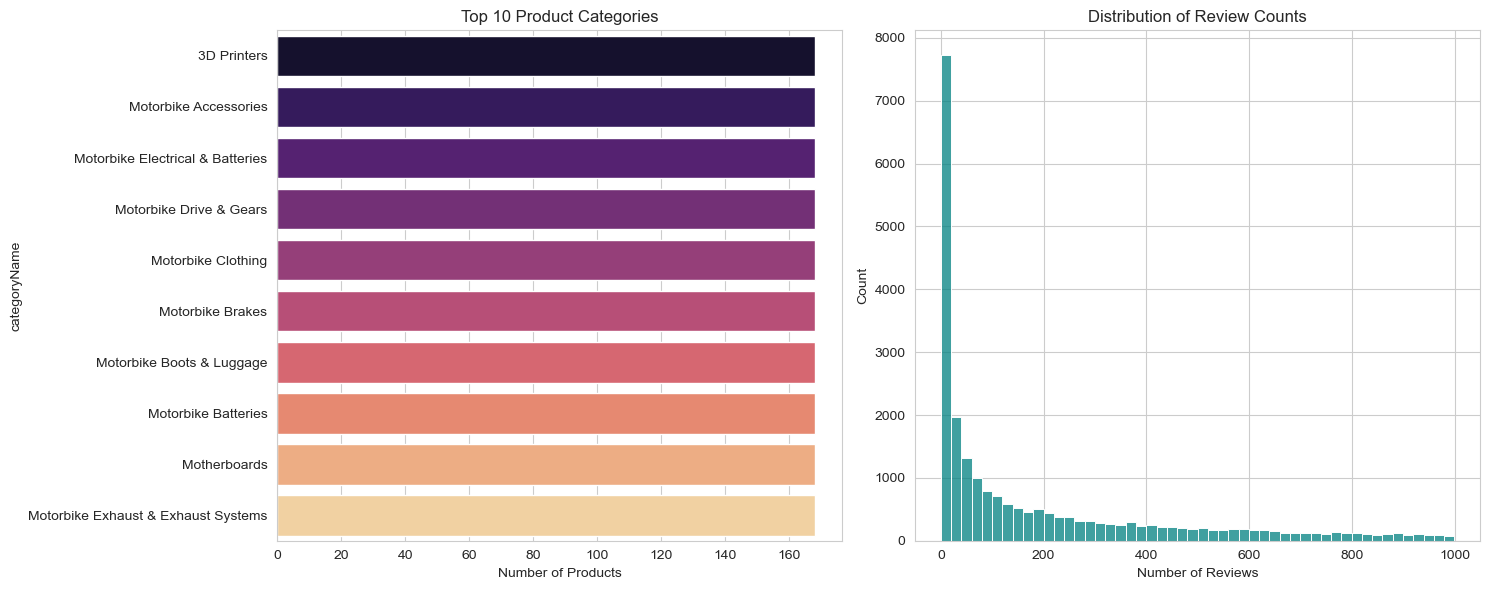

In [4]:
if not df_content.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Top Categories
    top_cats = df_content['categoryName'].value_counts().head(10)
    sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[0], palette='magma')
    axes[0].set_title("Top 10 Product Categories")
    axes[0].set_xlabel("Number of Products")

    # 2. Review Counts (Popularity)
    # Limiting to 1000 reviews for readability (removing extreme outliers)
    sns.histplot(df_content[df_content['reviews'] < 1000]['reviews'], bins=50, ax=axes[1], color='teal')
    axes[1].set_title("Distribution of Review Counts")
    axes[1].set_xlabel("Number of Reviews")

    plt.tight_layout()
    plt.show()

Model Training & Saving

In [5]:
if not df_content.empty:
    print("Initializing TF-IDF Vectorizer...")
    
    # 1. Define the AI Model (Vectorizer)
    # We limit to top 5000 words to keep it fast
    vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
    
    # 2. Train (Fit) the model on our data
    print("Training model (Vectorizing text)...")
    tfidf_matrix = vectorizer.fit_transform(df_content['tags'])
    
    print(f"✅ Training Complete. Matrix Shape: {tfidf_matrix.shape}")
    
    # 3. Save the Model
    print(f"Saving model to {MODEL_PATH}...")
    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    
    joblib.dump({
        'df': df_content,
        'vectorizer': vectorizer,
        'tfidf_matrix': tfidf_matrix
    }, MODEL_PATH)
    
    print("✅ Model saved successfully.")

Initializing TF-IDF Vectorizer...
Training model (Vectorizing text)...
✅ Training Complete. Matrix Shape: (48681, 5000)
Saving model to D:\Projects\orbit_recommender\models\content_engine.pkl...
✅ Model saved successfully.


Inference Setup

In [6]:
# Convert Sparse Matrix to Dense Array -> Tensor
print("Moving data to GPU/CPU for inference...")
tfidf_dense = tfidf_matrix.toarray()
tfidf_tensor = torch.tensor(tfidf_dense, dtype=torch.float32).to(device)

# Normalize for Cosine Similarity
tfidf_tensor = torch.nn.functional.normalize(tfidf_tensor, p=2, dim=1)

# Define the Search Function
def find_similar_products(product_id, k=5):
    # Find index of product in the DataFrame
    idx_list = df_content.index[df_content['asin'] == product_id].tolist()
    if not idx_list:
        return []
    idx = idx_list[0]
    
    # Get vector for this product
    query_vec = tfidf_tensor[idx].unsqueeze(0)
    
    # Calculate Cosine Similarity
    cosine_scores = torch.mm(query_vec, tfidf_tensor.transpose(0, 1))
    
    # Get Top K Scores
    scores, indices = torch.topk(cosine_scores, k=k+1)
    
    # Convert to readable format
    indices = indices.cpu().numpy().flatten()
    scores = scores.cpu().numpy().flatten()
    
    results = []
    # Skip index 0 (itself)
    for i in range(1, len(indices)):
        item_idx = indices[i]
        row = df_content.iloc[item_idx]
        results.append({
            "Title": row['title'],
            "Category": row['categoryName'],
            "Price": row['price'],
            "Match Score": round(float(scores[i]), 4)
        })
    return results

print("✅ Inference functions ready.")

Moving data to GPU/CPU for inference...
✅ Inference functions ready.


Inference Test

In [7]:
if not df_content.empty:
    # Pick a random product to test
    random_idx = np.random.randint(0, len(df_content))
    test_product = df_content.iloc[random_idx]
    
    print(f"🧪 Testing Recommendation for: {test_product['title']}")
    print(f"   Category: {test_product['categoryName']}\n")
    
    recommendations = find_similar_products(test_product['asin'], k=5)
    
    # Show results
    if recommendations:
        display(pd.DataFrame(recommendations))
    else:
        print("No recommendations found.")

🧪 Testing Recommendation for: Baofeng 2.5mm USB Charger Cable with Indicator Light for BaoFeng UV-5R UV-82 BF-F8HP UV-82HP UV-5X3 UV-5RE 3800mAh Battery UV-S9/9S Two Way Radio（2 Pack）
   Category: Radio Communication



,Title,Category,Price,Match Score
0,Mengshen USB Charger Cable Transformer Cable C...,Radio Communication,7.99,0.8769
1,Mengshen UV-82 Microphone Dual PTT Speaker Mic...,Radio Communication,8.79,0.7948
2,MIRKIT FTDI USB Baofeng Programming Cable 7 in...,Radio Communication,37.01,0.7701
3,Baofeng Walkie Talkie Baofeng UV-5R 1800mAh Ba...,Radio Communication,151.99,0.5302
4,RPT-2K Relay Walkie Talkie K-head Two Way Radi...,Radio Communication,34.03,0.4915
